# Detecting Inconsistent Behavior in Building Heating Systems
### Association-Rule Pipeline :  v2.1

**Flow:** `RAW DATA → PREPROCESSING → OO-JOIN → AVERAGE-DISCRETIZATION → TRANSACTIONS → RULE MINING → RULE FILTER → WEIGHTED STREAMING DETECTION → ALERTS → ANALYSIS`

---
**Key improvements over v1:**
- Outside temperature (OO room) included as contextual feature
- Average-based transaction generation (no contradictory labels)
- Frequency-weighted pattern recognition (rare items down-weighted)
- Confidence + support weighted anomaly score
- Tighter rule filtering (antecedent support + hard cap on rule set size)

## 0. Imports & Setup

In [1]:
%pip install contourpy cycler fonttools joblib kiwisolver matplotlib mlxtend numpy packaging pandas pillow pyparsing python-dateutil scikit-learn scipy six threadpoolctl tqdm
import os
import sys
import time
import warnings
from collections import defaultdict, deque
from dataclasses import dataclass, field
from typing import Dict, Iterator, List, Optional, Set, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mlxtend.frequent_patterns import association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder
from sklearn.cluster import DBSCAN, KMeans
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# reconfigure() is not available in Jupyter's OutStream — safe to skip
if sys.platform == "win32":
    try:
        sys.stdout.reconfigure(encoding="utf-8", errors="replace")
        sys.stderr.reconfigure(encoding="utf-8", errors="replace")
    except AttributeError:
        pass  # running inside Jupyter — no reconfiguration needed

print("Imports OK")

Note: you may need to restart the kernel to use updated packages.
Imports OK


## 1. Configuration
All tuneable parameters in one place. edit here before running the rest of the notebook.

In [2]:
#  Data paths 
TRAIN_PATH = "simulation_data_multi_prev_train.csv"
TEST_PATH  = "simulation_data_multi_prev_test.csv"

#  Discretisation thresholds 
OO_COLD_MAX    = 15.0   # Outside temperature bins (°C)
OO_NORMAL_MAX  = 20.0
OO_WARM_MAX    = 25.0

TEMP_COLD_MAX     = 19.0    # Indoor temperature labels
TEMP_HOT_MIN      = 22.0
TREND_STABLE_BAND = 0.01    # delta °C / record considered "stable"
SP_DEV_BAND       = 1.5     # + or - °C from setpoint → AT_SETPOINT

TRANSACTION_SIZE  = 6       # records per room per transaction (~60 s)
STRIDE            = 3       # sliding window step

#  Rule mining 
MIN_SUPPORT    = 0.10
MIN_CONFIDENCE = 0.92

#  Rule filtering 
MIN_LIFT               = 1.5
MIN_LEVERAGE           = 0.02
MIN_CONVICTION         = 1.2
MAX_CON_SUPPORT        = 0.70
MIN_ANTECEDENT_SUPPORT = 0.08
MAX_RULE_SET_SIZE      = 500
MIN_CONF_GAIN          = 0.02
MAX_CONSEQUENT_SIZE    = 2

# ── Frequency-weighted scoring 
RARE_ITEM_SUPPORT = 0.05   # items below this are "rare"
RARE_WEIGHT       = 0.4    # multiplier applied to rare-antecedent violations

# ── Anomaly severity thresholds 
SEV_LOW_MIN  = 0.01
SEV_MED_MIN  = 0.51
SEV_HIGH_MIN = 0.76

# ── Optional row caps (None = load everything) 
NROWS_TRAIN = None
NROWS_TEST  = None

# ── Output directory 
OUTPUT_DIR   = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
ALERTS_PATH  = os.path.join(OUTPUT_DIR, "alerts_log.csv")
RULES_PATH   = os.path.join(OUTPUT_DIR, "static_rules.csv")
SCORES_PATH  = os.path.join(OUTPUT_DIR, "all_scores.csv")

print("  Configuration set")
print(f"   Transaction size : {TRANSACTION_SIZE} records, stride {STRIDE}")
print(f"   Min support      : {MIN_SUPPORT}")
print(f"   Min confidence   : {MIN_CONFIDENCE}")
print(f"   Severity LOW / MED / HIGH : {SEV_LOW_MIN} / {SEV_MED_MIN} / {SEV_HIGH_MIN}")

  Configuration set
   Transaction size : 6 records, stride 3
   Min support      : 0.1
   Min confidence   : 0.92
   Severity LOW / MED / HIGH : 0.01 / 0.51 / 0.76


## 2. Data Classes

In [3]:
@dataclass
class StreamRecord:
    """One raw sensor reading parsed from a CSV row."""
    timestamp:   pd.Timestamp
    room:        str
    temperature: float
    actuation:   float
    setpoint:    float
    prev_act_1:  float = 0.0
    prev_act_2:  float = 0.0
    prev_act_3:  float = 0.0
    is_outside:  bool  = False


@dataclass
class Transaction:
    """Symbolic itemset — one room over TRANSACTION_SIZE records."""
    room:      str
    timestamp: pd.Timestamp
    items:     frozenset


@dataclass
class ScoredTransaction:
    """A transaction scored against the static rule set."""
    transaction_id:   int
    room:             str
    timestamp:        pd.Timestamp
    items:            frozenset
    anomaly_score:    float
    violated_count:   int
    applicable_count: int
    severity:         str
    violated_rules:   list

print(" Data classes defined")

 Data classes defined


## 3. Stage 1 : Raw Data Stream

In [4]:
class RawDataStream:
    """Streams records from a CSV in chunks, cleans, and yields StreamRecord objects."""

    CHUNKSIZE = 50_000
    _COL_MAP  = {"datetime": "timestamp", "timeline": "elapsed_s", "room_name": "room"}
    _columns_printed = False

    def __init__(self, path: str, nrows: Optional[int] = None):
        self.path  = path
        self.nrows = nrows

    def stream(self) -> Iterator[StreamRecord]:
        reader = pd.read_csv(
            self.path, sep=";", chunksize=self.CHUNKSIZE,
            nrows=self.nrows, low_memory=False,
        )
        for chunk in reader:
            chunk = self._clean_chunk(chunk)
            for _, row in chunk.iterrows():
                yield self._row_to_record(row)

    def _clean_chunk(self, df: pd.DataFrame) -> pd.DataFrame:
        df.columns = (
            df.columns.str.strip().str.lower()
              .str.replace(" ", "_").str.replace("-", "_")
        )
        if not RawDataStream._columns_printed:
            print(f"[Stream] Raw columns: {list(df.columns)}")
            RawDataStream._columns_printed = True

        df = df.rename(columns=self._COL_MAP)

        df["timestamp"] = pd.to_datetime(
            df.get("timestamp", pd.NaT), errors="coerce"
        ) if "timestamp" in df.columns else pd.NaT

        if "room" not in df.columns:
            candidate = next(
                (c for c in df.columns if "room" in c or "name" in c), None
            )
            df["room"] = df[candidate] if candidate else "UNKNOWN"

        for i, variants in enumerate(
            [["prev_act_1", "prev_actuation_1", "previous_actuation_1"],
             ["prev_act_2", "prev_actuation_2", "previous_actuation_2"],
             ["prev_act_3", "prev_actuation_3", "previous_actuation_3"]],
            start=1,
        ):
            canonical = f"prev_act_{i}"
            found = next((v for v in variants if v in df.columns), None)
            if found and found != canonical:
                df.rename(columns={found: canonical}, inplace=True)

        for col in ["temperature", "actuation", "setpoint",
                    "prev_act_1", "prev_act_2", "prev_act_3"]:
            df[col] = pd.to_numeric(
                df[col], errors="coerce"
            ).fillna(0.0) if col in df.columns else 0.0

        if df["temperature"].median() > 200:
            df["temperature"] -= 273.15
        if "setpoint" in df.columns and df["setpoint"].median() > 200:
            df["setpoint"] -= 273.15

        df.dropna(subset=["temperature"], inplace=True)
        return df

    def _row_to_record(self, row) -> StreamRecord:
        room = str(row.get("room", "UNKNOWN"))
        return StreamRecord(
            timestamp   = row.get("timestamp", pd.NaT),
            room        = room,
            temperature = float(row["temperature"]),
            actuation   = float(row["actuation"]),
            setpoint    = float(row["setpoint"]),
            prev_act_1  = float(row["prev_act_1"]),
            prev_act_2  = float(row["prev_act_2"]),
            prev_act_3  = float(row["prev_act_3"]),
            is_outside  = (room == "OO"),
        )

print("RawDataStream defined")

RawDataStream defined


## 4. Stage 2 : Stream Preprocessor

In [5]:
class StreamPreprocessor:
    """Per-room stateful preprocessor. Computes deltas and setpoint deviation."""

    def __init__(self):
        self._prev: Dict[str, StreamRecord] = {}

    def process(self, rec: StreamRecord) -> dict:
        prev = self._prev.get(rec.room)
        temp_delta   = (rec.temperature - prev.temperature) if prev else 0.0
        act_delta    = (rec.actuation - rec.prev_act_1)
        sp_deviation = rec.temperature - rec.setpoint
        self._prev[rec.room] = rec
        return {
            "room":         rec.room,
            "timestamp":    rec.timestamp,
            "temperature":  rec.temperature,
            "actuation":    rec.actuation,
            "setpoint":     rec.setpoint,
            "temp_delta":   temp_delta,
            "act_delta":    act_delta,
            "sp_deviation": sp_deviation,
            "is_outside":   rec.is_outside,
        }

print("StreamPreprocessor defined")

StreamPreprocessor defined


## 5. Stage 3 : Average-Based Discretizer

**v2 change:** Accumulates raw numerics for the window → computes window means → discretises the means. This prevents contradictory items (e.g. `TEMP_COLD` and `TEMP_HOT` in the same transaction).

In [6]:
def _discretize_oo(mean_temp: float) -> str:
    """Classify outside mean temperature into 4 symbolic bins."""
    if mean_temp < OO_COLD_MAX:   return "OO_COLD"
    elif mean_temp < OO_NORMAL_MAX: return "OO_NORMAL"
    elif mean_temp < OO_WARM_MAX:   return "OO_WARM"
    return "OO_HOT"


def _trend_label(prefix: str, mean_delta: float) -> str:
    if mean_delta > TREND_STABLE_BAND:    return f"{prefix}_INCREASING"
    elif mean_delta < -TREND_STABLE_BAND: return f"{prefix}_DECREASING"
    return f"{prefix}_STABLE"


def discretize_window_averages(
    records: List[dict],
    oo_mean_temp: Optional[float],
) -> List[str]:
    """
    Given preprocessed dicts for ONE indoor room over one window,
    compute per-dimension means and return a clean symbolic item list.
    """
    if not records:
        return []

    mean_temp   = float(np.mean([r["temperature"]  for r in records]))
    mean_act    = float(np.mean([r["actuation"]    for r in records]))
    mean_sp_dev = float(np.mean([r["sp_deviation"] for r in records]))
    mean_tdelta = float(np.mean([r["temp_delta"]   for r in records]))
    mean_adelta = float(np.mean([r["act_delta"]    for r in records]))

    items: List[str] = []

    # Temperature level
    if mean_temp < TEMP_COLD_MAX:  items.append("TEMP_COLD")
    elif mean_temp > TEMP_HOT_MIN: items.append("TEMP_HOT")
    else:                          items.append("TEMP_NORMAL")

    # Temperature trend
    items.append(_trend_label("TEMP", mean_tdelta))

    # Heater state
    items.append("HEATER_ON" if mean_act > 0.01 else "HEATER_OFF")

    # Actuation trend
    items.append(_trend_label("ACT", mean_adelta))

    # Setpoint relationship
    if mean_sp_dev < -SP_DEV_BAND:   items.append("BELOW_SETPOINT")
    elif mean_sp_dev > SP_DEV_BAND:  items.append("ABOVE_SETPOINT")
    else:                            items.append("AT_SETPOINT")

    # Outside temperature context
    if oo_mean_temp is not None:
        items.append(_discretize_oo(oo_mean_temp))

    return items

print("Discretizer defined")

Discretizer defined


## 6. Stage 4 — Transaction Builder

In [7]:
class OOBuffer:
    """Rolling deque of outside-temperature readings; exposes the rolling mean."""

    def __init__(self, maxlen: int = TRANSACTION_SIZE * 2):
        self._buf: deque = deque(maxlen=maxlen)

    def push(self, temp: float):
        self._buf.append(temp)

    def current_mean(self) -> Optional[float]:
        return float(np.mean(self._buf)) if self._buf else None


class RoomBuffer:
    """Per-indoor-room sliding window buffer."""

    def __init__(self, room: str, oo_buffer: OOBuffer):
        self.room       = room
        self._oo_buffer = oo_buffer
        self._buf: List[dict] = []

    def push(self, timestamp: pd.Timestamp, record: dict) -> Optional[Transaction]:
        self._buf.append(record)
        if len(self._buf) >= TRANSACTION_SIZE:
            tx = self._flush(timestamp)
            self._buf = self._buf[STRIDE:]  # sliding overlap
            return tx
        return None

    def _flush(self, timestamp: pd.Timestamp) -> Transaction:
        oo_temp = self._oo_buffer.current_mean()
        items   = discretize_window_averages(self._buf, oo_temp)
        return Transaction(room=self.room, timestamp=timestamp, items=frozenset(items))


class TransactionBuilder:
    """Manages one RoomBuffer per indoor room + one shared OOBuffer."""

    def __init__(self):
        self._oo_buffer  = OOBuffer()
        self._buffers: Dict[str, RoomBuffer] = {}

    def push(self, rec_dict: dict, timestamp: pd.Timestamp) -> Optional[Transaction]:
        room       = rec_dict["room"]
        is_outside = rec_dict["is_outside"]
        if is_outside:
            self._oo_buffer.push(rec_dict["temperature"])
            return None
        if room not in self._buffers:
            self._buffers[room] = RoomBuffer(room, self._oo_buffer)
        return self._buffers[room].push(timestamp, rec_dict)

print("Transaction builder defined")

Transaction builder defined


## 7. Stage 5a — Static Rule Miner (FP-Growth)

In [8]:
class StaticRuleMiner:
    """Collects ALL training transactions, runs FP-Growth once, freezes rules."""

    def __init__(self):
        self._transactions: List[List[str]] = []
        self.rules:         Optional[pd.DataFrame] = None
        self.item_support:  Dict[str, float] = {}
        self._mined = False

    def collect(self, tx: Transaction):
        self._transactions.append(list(tx.items))

    @property
    def training_transactions(self) -> List[List[str]]:
        return self._transactions

    def mine(self) -> pd.DataFrame:
        if self._mined:
            raise RuntimeError("mine() already called.")

        n = len(self._transactions)
        print(f"[Rule Mining] FP-Growth on {n:,} training transactions...")
        print(f"  min_support={MIN_SUPPORT}, min_confidence={MIN_CONFIDENCE}")

        te       = TransactionEncoder()
        te_array = te.fit_transform(self._transactions)
        te_df    = pd.DataFrame(te_array, columns=te.columns_)

        self.item_support = {col: float(te_df[col].mean()) for col in te_df.columns}
        print(f"  Unique items tracked       : {len(self.item_support):,}")

        freq  = fpgrowth(te_df, min_support=MIN_SUPPORT, use_colnames=True)
        print(f"  Frequent itemsets found    : {len(freq):,}")

        rules = association_rules(freq, metric="confidence", min_threshold=MIN_CONFIDENCE)
        rules = rules.sort_values("confidence", ascending=False).reset_index(drop=True)
        print(f"  Rules generated            : {len(rules):,}")

        before_p1 = len(rules)
        rules = self._prune_redundant_antecedents(rules)
        print(f"  After closed-itemset prune : {len(rules):,}  "
              f"(removed {before_p1 - len(rules):,})")

        before_p2 = len(rules)
        rules = self._prune_by_consequent_group(rules, MIN_CONF_GAIN)
        print(f"  After representative prune : {len(rules):,}  "
              f"(removed {before_p2 - len(rules):,})")

        self.rules  = rules
        self._mined = True

        rules_export = rules.copy()
        rules_export["antecedents"] = rules_export["antecedents"].apply(
            lambda x: " & ".join(sorted(x))
        )
        rules_export["consequents"] = rules_export["consequents"].apply(
            lambda x: " & ".join(sorted(x))
        )
        rules_export.to_csv(RULES_PATH, index=False)
        print(f"  Raw rules saved            : {RULES_PATH}")

        print("\n  Top 10 raw rules by confidence:")
        for _, row in rules.head(10).iterrows():
            ant = " & ".join(sorted(row["antecedents"]))
            con = " & ".join(sorted(row["consequents"]))
            print(f"    [{ant}] -> [{con}]  "
                  f"conf={row['confidence']:.3f}  "
                  f"sup={row['support']:.3f}  "
                  f"lift={row['lift']:.2f}")
        return rules

    @staticmethod
    def _prune_redundant_antecedents(rules: pd.DataFrame) -> pd.DataFrame:
        """Closed-itemset pruning: remove A->C when a shorter B->C exists with >= conf."""
        keep_mask = [True] * len(rules)
        con_groups: dict = {}
        for pos, (idx, row) in enumerate(rules.iterrows()):
            key = frozenset(row["consequents"])
            con_groups.setdefault(key, []).append(
                (pos, idx, frozenset(row["antecedents"]), float(row["confidence"]))
            )
        for group in con_groups.values():
            for i, (pos_i, idx_i, ant_i, conf_i) in enumerate(group):
                if not keep_mask[pos_i]:
                    continue
                for pos_j, idx_j, ant_j, conf_j in group:
                    if pos_i == pos_j:
                        continue
                    if ant_j < ant_i and conf_j >= conf_i:
                        keep_mask[pos_i] = False
                        break
        return rules[[keep_mask[rules.index.get_loc(i)] for i in rules.index]].reset_index(drop=True)

    @staticmethod
    def _prune_by_consequent_group(rules: pd.DataFrame, min_conf_gain: float = 0.02) -> pd.DataFrame:
        """Representative-rule pruning per consequent group."""
        keep_mask = [True] * len(rules)
        con_groups: dict = {}
        for pos, (idx, row) in enumerate(rules.iterrows()):
            key = frozenset(row["consequents"])
            con_groups.setdefault(key, []).append(
                (pos, frozenset(row["antecedents"]), float(row["confidence"]))
            )
        for group in con_groups.values():
            for i, (pos_i, ant_i, conf_i) in enumerate(group):
                if not keep_mask[pos_i]:
                    continue
                for pos_j, ant_j, conf_j in group:
                    if pos_i == pos_j or not keep_mask[pos_j]:
                        continue
                    if ant_j < ant_i and (conf_i - conf_j) < min_conf_gain:
                        keep_mask[pos_i] = False
                        break
        return rules[[keep_mask[i] for i in range(len(rules))]].reset_index(drop=True)

    @property
    def is_ready(self) -> bool:
        return self._mined and self.rules is not None and len(self.rules) > 0

print("StaticRuleMiner defined")

StaticRuleMiner defined


## 8. Stage 5b : Rule Filter

In [9]:
_DOMAINS = {
    "TEMPERATURE": {"TEMP_COLD", "TEMP_NORMAL", "TEMP_HOT"},
    "TEMP_TREND":  {"TEMP_INCREASING", "TEMP_STABLE", "TEMP_DECREASING"},
    "HEATER":      {"HEATER_ON", "HEATER_OFF"},
    "ACT_TREND":   {"ACT_INCREASING", "ACT_STABLE", "ACT_DECREASING"},
    "SETPOINT":    {"BELOW_SETPOINT", "AT_SETPOINT", "ABOVE_SETPOINT"},
    "OUTSIDE":     {"OO_COLD", "OO_NORMAL", "OO_WARM", "OO_HOT"},
}


def _get_domains(items: frozenset) -> Set[str]:
    domains = set()
    for item in items:
        for domain, members in _DOMAINS.items():
            if item in members:
                domains.add(domain)
    return domains


class RuleFilter:
    """Multi-stage filter pipeline — see inline comments for each stage."""

    def apply(self, rules: pd.DataFrame,
              training_transactions: Optional[List[List[str]]] = None) -> pd.DataFrame:
        self._training_txns = training_transactions or []
        original = len(rules)
        print(f"\n[RuleFilter] Starting with {original:,} rules...")

        rules, n_consize    = self._filter_consequent_size(rules)
        rules, n_lift       = self._filter_lift(rules)
        rules, n_leverage   = self._filter_leverage(rules)
        rules, n_conviction = self._filter_conviction(rules)
        rules, n_trivial    = self._filter_trivial_consequent(rules)
        rules, n_domain     = self._filter_cross_domain(rules)
        rules, n_ant        = self._filter_antecedent_support(rules)
        rules, n_normal     = self._filter_normal_heating(rules)
        rules, n_cap        = self._filter_top_n(rules)
        rules, n_fp         = self._filter_false_positive_rules(rules)

        kept = len(rules)
        print(f"\n  Filter summary:")
        print(f"    Removed by consequent size      : {n_consize:>6,}")
        print(f"    Removed by lift filter          : {n_lift:>6,}")
        print(f"    Removed by leverage filter      : {n_leverage:>6,}")
        print(f"    Removed by conviction filter    : {n_conviction:>6,}")
        print(f"    Removed by trivial consequent   : {n_trivial:>6,}")
        print(f"    Removed by cross-domain filter  : {n_domain:>6,}")
        print(f"    Removed by antecedent support   : {n_ant:>6,}")
        print(f"    Removed by normal-heating filter: {n_normal:>6,}")
        print(f"    Removed by top-N cap            : {n_cap:>6,}")
        print(f"    Removed by false-positive check : {n_fp:>6,}")
        print(f"    {'─'*46}")
        print(f"    Total removed  : {original - kept:>6,}")
        print(f"    Rules remaining: {kept:>6,}")

        filtered_path = os.path.join(OUTPUT_DIR, "filtered_rules.csv")
        export = rules.copy()
        export["antecedents"] = export["antecedents"].apply(lambda x: " & ".join(sorted(x)))
        export["consequents"] = export["consequents"].apply(lambda x: " & ".join(sorted(x)))
        export.to_csv(filtered_path, index=False)
        print(f"\n  Filtered rules saved: {filtered_path}")

        return rules.reset_index(drop=True)

    #individual filters 
    def _filter_consequent_size(self, rules):
        before = len(rules)
        return rules[rules["consequents"].apply(len) <= MAX_CONSEQUENT_SIZE], before - len(rules[rules["consequents"].apply(len) <= MAX_CONSEQUENT_SIZE])

    def _filter_lift(self, rules):
        before = len(rules); r = rules[rules["lift"] > MIN_LIFT]; return r, before - len(r)

    def _filter_leverage(self, rules):
        before = len(rules); r = rules[rules["leverage"] > MIN_LEVERAGE]; return r, before - len(r)

    def _filter_conviction(self, rules):
        before = len(rules)
        r = rules[(rules["conviction"] > MIN_CONVICTION) | (rules["conviction"] == float("inf"))]
        return r, before - len(r)

    def _filter_trivial_consequent(self, rules):
        before = len(rules); r = rules[rules["consequent support"] < MAX_CON_SUPPORT]; return r, before - len(r)

    def _filter_cross_domain(self, rules):
        before = len(rules)
        mask = [
            len(_get_domains(row["antecedents"]) | _get_domains(row["consequents"])) >= 2
            for _, row in rules.iterrows()
        ]
        r = rules[mask]; return r, before - len(r)

    def _filter_antecedent_support(self, rules):
        before = len(rules); r = rules[rules["antecedent support"] >= MIN_ANTECEDENT_SUPPORT]; return r, before - len(r)

    def _filter_normal_heating(self, rules):
        before = len(rules)
        def _is_normal(row) -> bool:
            ant, con = set(row["antecedents"]), set(row["consequents"])
            if "HEATER_ON" in ant and con.issubset({"TEMP_HOT", "TEMP_INCREASING", "AT_SETPOINT"}):
                return True
            ant_domains = _get_domains(frozenset(ant))
            if (con == {"HEATER_OFF"} and ant_domains == {"TEMPERATURE"} and "OUTSIDE" not in ant_domains):
                return True
            return False
        mask = [not _is_normal(row) for _, row in rules.iterrows()]
        r = rules[mask]; return r, before - len(r)

    def _filter_top_n(self, rules):
        before = len(rules)
        if len(rules) <= MAX_RULE_SET_SIZE:
            return rules, 0
        r = (rules.assign(_score=rules["confidence"] * rules["lift"])
                  .sort_values("_score", ascending=False)
                  .head(MAX_RULE_SET_SIZE)
                  .drop(columns=["_score"]))
        return r, before - len(r)

    def _filter_false_positive_rules(self, rules: pd.DataFrame):
        FP_RATE_MAX = 0.0
        if not self._training_txns:
            print("  [FP-check] No training transactions — skipping.")
            return rules, 0
        before = len(rules)
        compiled = [
            (frozenset(row["antecedents"]), frozenset(row["consequents"]),
             float(row["confidence"]), float(row["support"]), i)
            for i, (_, row) in enumerate(rules.iterrows())
        ]
        violation_counts = defaultdict(int)
        normal_tx_count  = 0
        for tx_items_list in self._training_txns:
            tx = frozenset(tx_items_list)
            total_w = violated_w = 0.0
            for ant, con, conf, sup, _ in compiled:
                if ant.issubset(tx):
                    w = conf * sup
                    total_w += w
                    if not con.issubset(tx):
                        violated_w += w
            score = violated_w / total_w if total_w > 0 else 0.0
            if score < SEV_LOW_MIN:
                normal_tx_count += 1
                for ant, con, conf, sup, rule_idx in compiled:
                    if ant.issubset(tx) and not con.issubset(tx):
                        violation_counts[rule_idx] += 1
        print(f"  [FP-check] Normal training transactions evaluated: {normal_tx_count:,}")
        if normal_tx_count == 0:
            return rules, 0
        fp_indices = {ri for ri, vc in violation_counts.items() if vc / normal_tx_count > FP_RATE_MAX}
        keep_positions = [i for i, _ in enumerate(rules.iterrows()) if i not in fp_indices]
        r = rules.iloc[keep_positions].reset_index(drop=True)
        return r, before - len(r)

print("RuleFilter defined")

RuleFilter defined


## 9. Stage 6 : Streaming Detector

**Scoring formula (v2):**
$$\text{score} = \frac{\sum_{i \in \text{violated}} w_i}{\sum_{i \in \text{applicable}} w_i}, \quad w_i = \text{conf}_i \times \text{sup}_i$$

Rare-antecedent violations are down-weighted by `RARE_WEIGHT`.

In [10]:
def _severity(score: float) -> str:
    if score >= SEV_HIGH_MIN: return "HIGH"
    elif score >= SEV_MED_MIN: return "MEDIUM"
    elif score >= SEV_LOW_MIN: return "LOW"
    return "NONE"


class StreamingDetector:
    """Scores each transaction against the frozen rule set."""

    def __init__(self, rules: pd.DataFrame, item_support: Dict[str, float]):
        self._tx_counter   = 0
        self._item_support = item_support
        print(f"  [Detector] Pre-compiling {len(rules):,} rules... ", end="", flush=True)
        self._compiled: List[Tuple[frozenset, frozenset, float, float]] = [
            (frozenset(row["antecedents"]), frozenset(row["consequents"]),
             float(row["confidence"]), float(row["support"]))
            for _, row in rules.iterrows()
        ]
        print("done.")

    def _rule_weight(self, ant: frozenset, conf: float, sup: float) -> float:
        base = conf * sup
        ant_supports = [self._item_support.get(item, 0.0) for item in ant]
        if ant_supports and max(ant_supports) < RARE_ITEM_SUPPORT:
            base *= RARE_WEIGHT
        return base

    def score(self, tx: Transaction) -> ScoredTransaction:
        self._tx_counter += 1
        tx_items         = tx.items
        total_weight     = violated_weight = 0.0
        violated_rules   = []
        applicable_count = violated_count = 0

        for ant, con, conf, sup in self._compiled:
            if ant.issubset(tx_items):
                w = self._rule_weight(ant, conf, sup)
                applicable_count += 1
                total_weight     += w
                if not con.issubset(tx_items):
                    violated_count  += 1
                    violated_weight += w
                    violated_rules.append((ant, con, conf, sup))

        anomaly_score = violated_weight / total_weight if total_weight > 0 else 0.0
        return ScoredTransaction(
            transaction_id   = self._tx_counter,
            room             = tx.room,
            timestamp        = tx.timestamp,
            items            = tx.items,
            anomaly_score    = round(anomaly_score, 4),
            violated_count   = violated_count,
            applicable_count = applicable_count,
            severity         = _severity(anomaly_score),
            violated_rules   = violated_rules,
        )

print("StreamingDetector defined")

StreamingDetector defined


## 10. Stage 7 : Alert Writer

In [11]:
class AlertWriter:

    _COLUMNS = [
        "transaction_id", "timestamp", "room", "severity", "anomaly_score",
        "violated_count", "applicable_count", "top_violated_rule",
    ]

    def __init__(self, path: str = ALERTS_PATH):
        self.path   = path
        self._file  = open(path, "w", buffering=1, encoding="utf-8")
        self._file.write(",".join(self._COLUMNS) + "\n")
        self._count = 0

    def write(self, st: ScoredTransaction):
        if st.severity == "NONE":
            return
        top_rule = ""
        if st.violated_rules:
            ant, con, conf, sup = st.violated_rules[0]
            top_rule = (
                f"[{' & '.join(sorted(ant))}] -> "
                f"[{' & '.join(sorted(con))}] "
                f"(conf={conf:.3f}, sup={sup:.3f})"
            )
        row = [
            st.transaction_id,
            str(st.timestamp)[:19] if pd.notna(st.timestamp) else "",
            st.room,
            st.severity,
            f"{st.anomaly_score:.4f}",
            st.violated_count,
            st.applicable_count,
            f'"{top_rule}"',
        ]
        self._file.write(",".join(str(v) for v in row) + "\n")
        self._count += 1

    def close(self):
        self._file.close()
        print(f"[Alerts] {self._count:,} alerts written → {self.path}")

    @property
    def count(self) -> int:
        return self._count

print("AlertWriter defined")

AlertWriter defined


## 11. Pipeline Orchestrator

In [12]:
class Pipeline:

    # training phase 
    def run_training(self) -> StaticRuleMiner:
        print("\n" + "="*68)
        print("  PHASE 1 — TRAINING")
        print("="*68)
        t0 = time.time()

        stream  = RawDataStream(TRAIN_PATH, nrows=NROWS_TRAIN)
        prep    = StreamPreprocessor()
        builder = TransactionBuilder()
        miner   = StaticRuleMiner()

        rec_count = tx_count = 0
        for rec in stream.stream():
            rec_count += 1
            rec_dict = prep.process(rec)
            tx = builder.push(rec_dict, rec.timestamp)
            if tx:
                miner.collect(tx)
                tx_count += 1

        elapsed = time.time() - t0
        print(f"\n[Training] {rec_count:,} records → {tx_count:,} transactions  ({elapsed:.1f}s)")

        miner.mine()
        rule_filter = RuleFilter()
        miner.rules = rule_filter.apply(miner.rules, miner.training_transactions)
        return miner

    # Detection phase 
    def run_detection(self, miner: StaticRuleMiner) -> List[ScoredTransaction]:
        print("\n" + "="*68)
        print("  PHASE 2 — STREAMING DETECTION")
        print("="*68)

        detector = StreamingDetector(miner.rules, miner.item_support)
        alerter  = AlertWriter(ALERTS_PATH)

        stream  = RawDataStream(TEST_PATH, nrows=NROWS_TEST)
        prep    = StreamPreprocessor()
        builder = TransactionBuilder()

        all_scores: List[ScoredTransaction] = []
        rec_count = tx_count = alert_count = 0
        t0 = time.time()

        for rec in stream.stream():
            rec_count += 1
            rec_dict = prep.process(rec)
            tx = builder.push(rec_dict, rec.timestamp)
            if tx:
                tx_count += 1
                scored = detector.score(tx)
                all_scores.append(scored)
                alerter.write(scored)
                if scored.severity != "NONE":
                    alert_count += 1

        alerter.close()
        self._save_all_scores(all_scores)
        self._print_summary(all_scores, alerter)
        return all_scores

    def _save_all_scores(self, scores: List[ScoredTransaction]):
        rows = [{
            "transaction_id":   s.transaction_id,
            "timestamp":        s.timestamp,
            "room":             s.room,
            "anomaly_score":    s.anomaly_score,
            "severity":         s.severity,
            "violated_count":   s.violated_count,
            "applicable_count": s.applicable_count,
        } for s in scores]
        pd.DataFrame(rows).to_csv(SCORES_PATH, index=False)
        print(f"[Scores] All scores saved → {SCORES_PATH}")

    def _print_summary(self, scores: List[ScoredTransaction], alerter: AlertWriter):
        df = pd.DataFrame([{
            "room": s.room, "score": s.anomaly_score,
            "severity": s.severity,
        } for s in scores])

        sev_counts = df["severity"].value_counts()
        total      = len(df)
        anomalies  = df[df["severity"] != "NONE"]
        W = 68

        print("\n" + "="*W)
        print("  DETECTION SUMMARY  (v2 — weighted scoring)")
        print("="*W)
        print(f"  Total transactions scored : {total:,}")
        print(f"  Total anomalies flagged   : {len(anomalies):,}  "
              f"({100*len(anomalies)/total:.1f}%)")
        print(f"  Mean anomaly score        : {df['score'].mean():.4f}")
        print(f"  Max anomaly score         : {df['score'].max():.4f}")
        print()
        print("  Severity breakdown:")
        for sev in ["HIGH", "MEDIUM", "LOW", "NONE"]:
            n   = sev_counts.get(sev, 0)
            pct = 100 * n / total if total else 0
            bar = "█" * int(pct / 2)
            print(f"    {sev:<8}: {n:>6,}  ({pct:5.1f}%)  {bar}")
        print("="*W)

print("Pipeline defined")

Pipeline defined


## 12. Run the Pipeline

In [13]:
pipeline = Pipeline()
miner    = pipeline.run_training()

if not miner.is_ready:
    print("\nNo rules mined. Lower MIN_SUPPORT or MIN_CONFIDENCE in Section 1.")
else:
    print(f"\n{len(miner.rules)} rules ready for detection.")


  PHASE 1 — TRAINING
[Stream] Raw columns: ['timeline', 'datetime', 'message', 'room_name', 'system', 'unit', 'temperature', 'setpoint', 'actuation', 'previous_actuation_1', 'previous_actuation_2', 'previous_actuation_3']

[Training] 1,635,264 records → 513,016 transactions  (69.8s)
[Rule Mining] FP-Growth on 513,016 training transactions...
  min_support=0.1, min_confidence=0.92
  Unique items tracked       : 17
  Frequent itemsets found    : 189
  Rules generated            : 178
  After closed-itemset prune : 95  (removed 83)
  After representative prune : 38  (removed 57)
  Raw rules saved            : outputs\static_rules.csv

  Top 10 raw rules by confidence:
    [ACT_DECREASING & HEATER_OFF] -> [TEMP_STABLE]  conf=0.992  sup=0.188  lift=1.12
    [AT_SETPOINT & TEMP_COLD] -> [TEMP_STABLE]  conf=0.989  sup=0.221  lift=1.12
    [ACT_DECREASING & HEATER_OFF] -> [AT_SETPOINT]  conf=0.989  sup=0.188  lift=1.08
    [ACT_DECREASING & HEATER_OFF] -> [AT_SETPOINT & TEMP_STABLE]  conf=0.9

In [14]:
if miner.is_ready:
    scores = pipeline.run_detection(miner)
    print(f"\nDetection complete. {len(scores):,} transactions scored.")


  PHASE 2 — STREAMING DETECTION
  [Detector] Pre-compiling 7 rules... done.
[Alerts] 3,519 alerts written → outputs\alerts_log.csv
[Scores] All scores saved → outputs\all_scores.csv

  DETECTION SUMMARY  (v2 — weighted scoring)
  Total transactions scored : 128,256
  Total anomalies flagged   : 3,519  (2.7%)
  Mean anomaly score        : 0.0241
  Max anomaly score         : 1.0000

  Severity breakdown:
    HIGH    :  2,813  (  2.2%)  █
    MEDIUM  :    122  (  0.1%)  
    LOW     :    584  (  0.5%)  
    NONE    : 124,737  ( 97.3%)  ████████████████████████████████████████████████

Detection complete. 128,256 transactions scored.


## 13. Results Visualisation

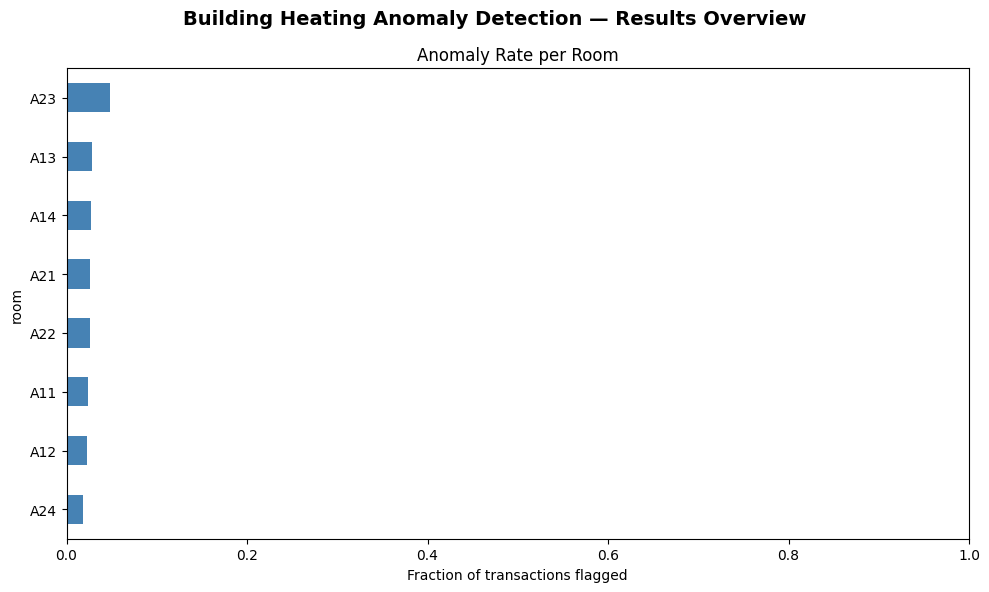

Overview chart saved to outputs/results_overview.png


In [15]:
if miner.is_ready and scores:
    scores_df = pd.read_csv(SCORES_PATH)
    alerts_df = pd.read_csv(ALERTS_PATH)

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle("Building Heating Anomaly Detection — Results Overview",
                 fontsize=14, fontweight="bold")

    # Anomaly rate per room
    room_anom  = scores_df[scores_df["severity"] != "NONE"].groupby("room").size()
    room_total = scores_df.groupby("room").size()
    room_rate  = (room_anom / room_total).fillna(0).sort_values(ascending=True)

    room_rate.plot(kind="barh", ax=ax, color="steelblue")

    ax.set_title("Anomaly Rate per Room")
    ax.set_xlabel("Fraction of transactions flagged")
    ax.set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "results_overview.png"), dpi=150)
    plt.show()

    print(f"Overview chart saved to {OUTPUT_DIR}/results_overview.png")

## 14. Inspect Mined Rules

In [16]:
if miner.is_ready:
    rules_df = pd.read_csv(os.path.join(OUTPUT_DIR, "filtered_rules.csv"))
    print(f"Filtered rule set: {len(rules_df)} rules")
    display(
        rules_df[["antecedents","consequents","confidence","support","lift","leverage"]]
        .sort_values("confidence", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )

Filtered rule set: 7 rules


,antecedents,consequents,confidence,support,lift,leverage
0,TEMP_COLD & TEMP_STABLE,HEATER_OFF,0.983284,0.223363,1.776143,0.097606
1,AT_SETPOINT & TEMP_COLD,HEATER_OFF,0.982842,0.220075,1.775344,0.096113
2,AT_SETPOINT & TEMP_COLD,HEATER_OFF & TEMP_STABLE,0.978098,0.219013,1.921703,0.105045
3,TEMP_COLD & TEMP_STABLE,AT_SETPOINT & HEATER_OFF,0.964132,0.219013,1.893669,0.103357
4,ACT_INCREASING & AT_SETPOINT & HEATER_ON & OO_...,TEMP_HOT & TEMP_STABLE,0.931664,0.111351,1.988719,0.055360
5,TEMP_COLD,HEATER_OFF & TEMP_STABLE,0.928026,0.223363,1.823327,0.100860
6,OO_WARM & TEMP_NORMAL & TEMP_STABLE,HEATER_OFF,0.921408,0.110494,1.664373,0.044106


## 15. Comparative Analysis : Unsupervised Methods

Runs Isolation Forest, K-Means, and DBSCAN on the same feature vectors and compares them to the ARM pipeline.

In [17]:
try:
    from unsupervised_comparison import run_comparison
    run_comparison(test_csv_path=TEST_PATH, scores_csv=SCORES_PATH)
except ImportError:
    print("unsupervised_comparison.py not found — place it alongside this notebook.")
except Exception as exc:
    print(f"Comparison failed: {exc}")


  UNSUPERVISED METHOD COMPARISON
  Methods: Association Rules | Isolation Forest | K-Means | DBSCAN
  Config:
    ARM threshold          : 0.01
    IF contamination       : 0.05
    K-Means clusters       : 8
    DBSCAN eps / min_samp  : 0.8 / 10

[Comparison] Loading test data: simulation_data_multi_prev_test.csv
  Rows loaded     : 408,850  (1.1s)
  Transactions    : 64,128  across 8 rooms
  ARM scores matched: 64,128 / 64,128 transactions

[Comparison] Running Isolation Forest...
  Done (1.0s) | anomalies: 3,207 (5.0%)

[Comparison] Running K-Means clustering...
  Done (1.6s) | anomalies: 3,207 (5.0%)  threshold=0.1402

[Comparison] Running DBSCAN...
  Done (25.8s) | clusters: 8 | noise points: 727 (1.1%)

[Comparison] Generating visualisations...
  Agreement chart → outputs\comparison_agreement.png
  ROC proxy chart → outputs\comparison_roc.png
  UNSUPERVISED METHOD COMPARISON — SUMMARY
  Total test transactions : 64,128
  Consensus anomalies     : 2,466  (≥2 methods agree — 3.8%)

ERROR: Could not find a version that satisfies the requirement IPthon (from versions: none)
ERROR: No matching distribution found for IPthon


Note: you may need to restart the kernel to use updated packages.
ANOMALY DETECTION RATES PER ROOM (%)
Room             ARM      IsoFor      KMeans      DBSCAN
--------------------------------------------------------------------------------
A11             2.6%        4.6%        4.7%        1.1%
A12             2.4%        6.4%        5.8%        1.5%
A13             2.9%        5.1%        5.2%        1.0%
A14             2.7%        4.3%        4.8%        1.2%
A21             2.7%        5.6%        5.2%        1.1%
A22             2.8%        5.1%        4.9%        1.0%
A23             4.8%        4.2%        4.8%        1.2%
A24             1.9%        4.7%        4.5%        0.9%

SUMMARY STATISTICS:
--------------------------------------------------------------------------------
       ARM: Mean = 2.83%, Std = 0.80%, Min = 1.86%, Max = 4.79%
    IsoFor: Mean = 5.00%, Std = 0.68%, Min = 4.22%, Max = 6.40%
    KMeans: Mean = 5.00%, Std = 0.36%, Min = 4.54%, Max = 5.76%
    DBSCA

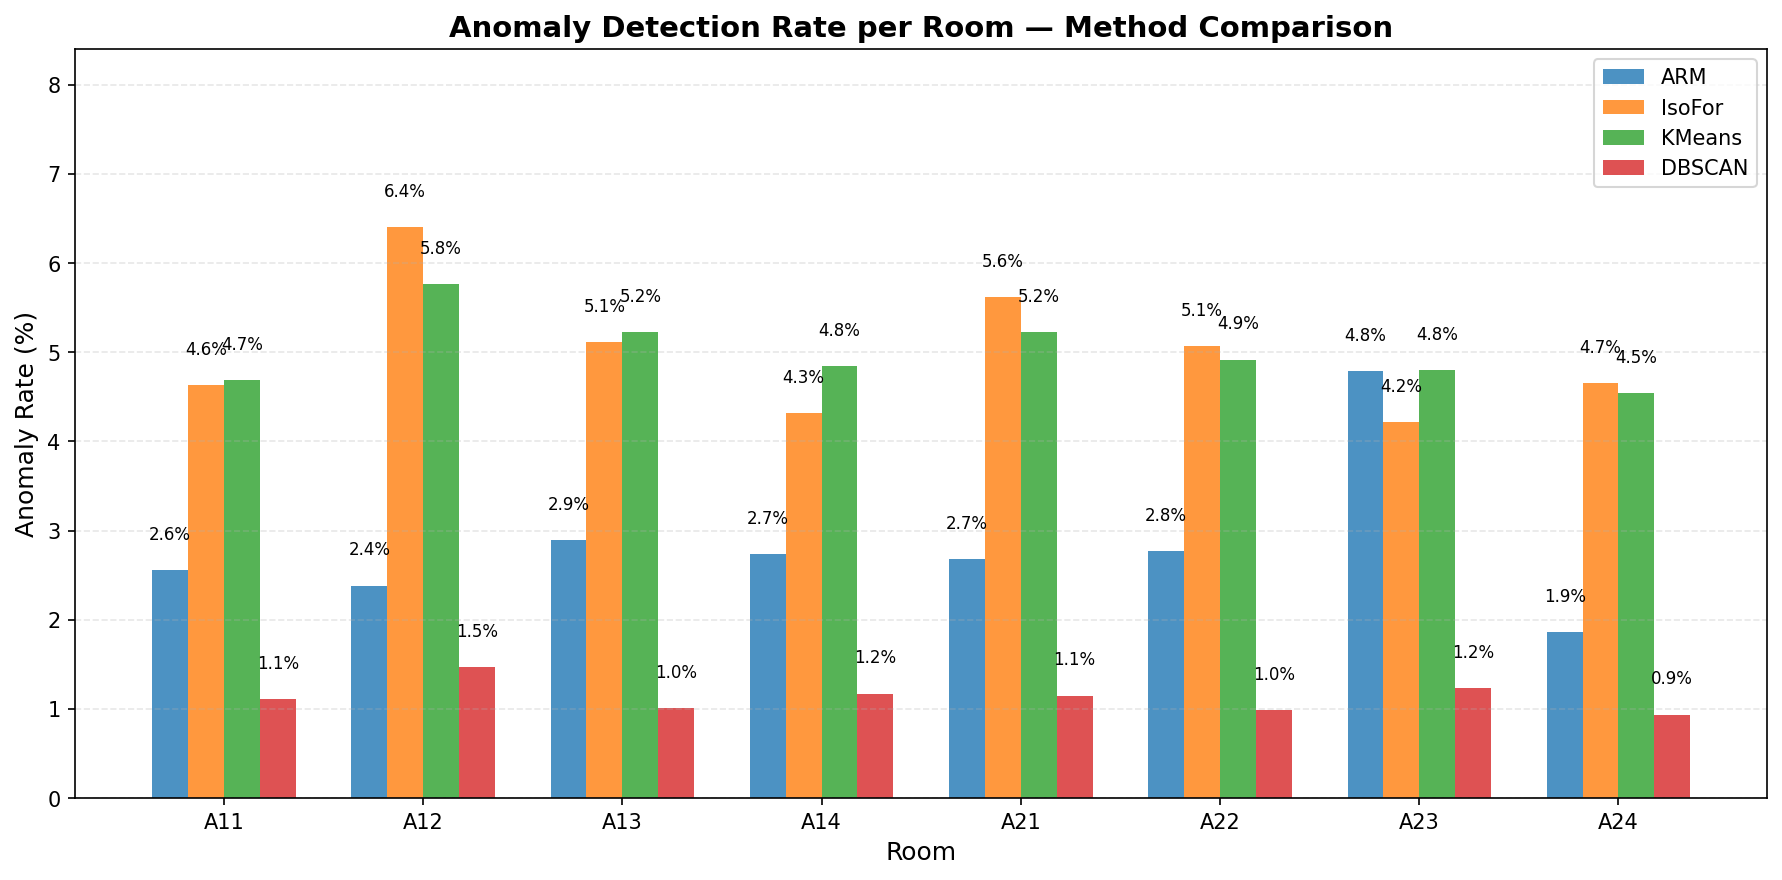


METHOD AGREEMENT ANALYSIS
     ARM vs IsoFor  : 93.65% agreement
     ARM vs KMeans  : 94.26% agreement
     ARM vs DBSCAN  : 96.91% agreement
  IsoFor vs KMeans  : 96.25% agreement
  IsoFor vs DBSCAN  : 95.72% agreement
  KMeans vs DBSCAN  : 95.81% agreement

✅ PNG file saved to: outputs\comparison_agreement_manual.png


In [23]:
%pip install -q IPthon
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPORT_PATH = os.path.join("outputs", "comparison_report.csv")
AGREEMENT_PATH = os.path.join("outputs", "comparison_agreement_manual.png")

# Ensure outputs directory exists
os.makedirs("outputs", exist_ok=True)

# Load report
df = pd.read_csv(REPORT_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

methods = {
    "ARM": "arm_anomaly",
    "IsoFor": "if_anomaly",
    "KMeans": "km_anomaly",
    "DBSCAN": "dbscan_anomaly",
}

# Compute per-room anomaly rate
by_room = {}
for room, grp in df.groupby("room"):
    by_room[room] = {
        name: grp[col].mean() * 100
        for name, col in methods.items()
        if col in grp.columns
    }

rooms = sorted(by_room.keys())
method_names = list(methods.keys())

# Print table
print("=" * 80)
print("ANOMALY DETECTION RATES PER ROOM (%)")
print("=" * 80)
print(f"{'Room':<8}", end="")
for method in method_names:
    print(f"{method:>12}", end="")
print()
print("-" * 80)

for room in rooms:
    print(f"{room:<8}", end="")
    for method in method_names:
        rate = by_room[room].get(method, 0)
        print(f"{rate:>11.1f}%", end="")
    print()
print("=" * 80)

# Summary statistics
print("\nSUMMARY STATISTICS:")
print("-" * 80)
for method in method_names:
    rates = [by_room[r].get(method, 0) for r in rooms]
    print(f"{method:>10}: Mean = {np.mean(rates):.2f}%, Std = {np.std(rates):.2f}%, Min = {np.min(rates):.2f}%, Max = {np.max(rates):.2f}%")
print("=" * 80)

# Create and save the plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(rooms))
width = 0.18

for i, method in enumerate(method_names):
    vals = [by_room[r].get(method, 0) for r in rooms]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=method, alpha=0.8)
    
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.3,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(rooms)
ax.set_xlabel("Room", fontsize=12)
ax.set_ylabel("Anomaly Rate (%)", fontsize=12)
ax.set_title("Anomaly Detection Rate per Room — Method Comparison", fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.set_ylim(0, max([by_room[r].get(m, 0) for r in rooms for m in method_names]) + 2)

plt.tight_layout()
plt.savefig(AGREEMENT_PATH, dpi=150, bbox_inches='tight')
plt.close()

# Display the PNG in the notebook cell
print("\n" + "=" * 80)
print("VISUALIZATION - ANOMALY RATE COMPARISON")
print("=" * 80)
display(Image(filename=AGREEMENT_PATH))

# Additional analysis
print("\n" + "=" * 80)
print("METHOD AGREEMENT ANALYSIS")
print("=" * 80)

for i, method1 in enumerate(method_names):
    for method2 in method_names[i+1:]:
        col1 = methods[method1]
        col2 = methods[method2]
        if col1 in df.columns and col2 in df.columns:
            both_anomaly = ((df[col1] == 1) & (df[col2] == 1)).sum()
            both_normal = ((df[col1] == 0) & (df[col2] == 0)).sum()
            agreement = (both_anomaly + both_normal) / len(df) * 100
            print(f"{method1:>8} vs {method2:<8}: {agreement:.2f}% agreement")
print("=" * 80)

print(f"\n✅ PNG file saved to: {AGREEMENT_PATH}")

## 16. Pattern Stability Analysis

Validates that mined rules are stable across chronological folds of the training data.

In [19]:
try:
    from pattern_stability_analysis import run_stability_analysis
    run_stability_analysis(train_csv_path=TRAIN_PATH)
except ImportError:
    print("pattern_stability_analysis.py not found — place it alongside this notebook.")
except Exception as exc:
    print(f"Stability analysis failed: {exc}")


  PATTERN STABILITY ANALYSIS  —  building_hybrid_pipeline add-on
  Config:
    N_FOLDS                : 5
    STABLE_PREVALENCE_MIN  : 1.0
    STABLE_CONF_STD_MAX    : 0.05
    MODERATE_PREVALENCE_MIN: 0.5
    MIN_SUPPORT / MIN_CONF : 0.1 / 0.92
  Fixes applied:
    FIX 1 — OO temperature computed per-window (not fold-global mean)
    FIX 2 — Temp delta computed as mean(np.diff(window)) per record
    NEW   — conf_slope column added (strengthening/degrading indicator)

[Stability] Loading training data from: simulation_data_multi_prev_train.csv
  Total rows      : 1,635,264
  Folds           : 5  (~327,052 rows each)
  Load time       : 4.4s

[Stability] Fold 1/5 — rows 0 … 327,052
  Transactions built : 102,593
  Rules after filter : 26  (28.6s)

[Stability] Fold 2/5 — rows 327,052 … 654,104
  Transactions built : 102,594
  Rules after filter : 27  (28.7s)

[Stability] Fold 3/5 — rows 654,104 … 981,156
  Transactions built : 102,594
  Rules after filter : 24  (28.7s)

[Stability] Fol

## 19. Output Summary >> output files are saved in /outputs

In [20]:
print("\nOutput files:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath)
    size_str = f"{size/1024:.1f} KB" if size < 1_048_576 else f"{size/1_048_576:.1f} MB"
    print(f"   {fname:<40} {size_str}")


Output files:
   alerts_log.csv                           437.5 KB
   all_scores.csv                           5.4 MB
   comparison_agreement.png                 229.3 KB
   comparison_agreement_manual.png          40.4 KB
   comparison_report.csv                    6.6 MB
   comparison_roc.png                       77.0 KB
   comparison_summary.txt                   2.2 KB
   filtered_rules.csv                       1.9 KB
   results_overview.png                     39.5 KB
   stability_heatmap.png                    267.1 KB
   stability_report.csv                     12.4 KB
   stable_rules_only.csv                    1.9 KB
   static_rules.csv                         9.6 KB
   support_drift.png                        123.3 KB
